# Specific Stock Simulation

Get the historical daily data for one ticker, run the prediction analysis across the full history, simulate trades from the resulting daily signals, and show a consolidated chart with price, trade markers, and portfolio value.

Trading rules:
- `STRONG BUY`: buy stock worth 10% of `initial_funds`
- `WEAK BUY`: buy stock worth 5% of `initial_funds`
- `HOLD`: do nothing
- `WEAK SELL`: sell 5% of current holdings
- `STRONG SELL`: sell 10% of current holdings

Fractional shares are allowed.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import analysis_blocks


## Block 1: Parameters


In [2]:
ticker = "PDD"
initial_funds = 10000
include_fundamentals = True
include_sentiment = False  # True requires API keys and adds latency


In [3]:

df_pred = analysis_blocks.build_prediction_frame(
            ticker,
            include_sentiment=include_sentiment
        )
df_pred

,Date,Open,High,Low,Close,Adj Close,Volume,TICKER,SMA10,SMA20,...,VWAP,Daily_Return,Cumulative_Return,Daily Gain/Loss,technical_analysis_buy_score,technical_analysis_sell_score,fundamental_analysis_score,sentiment_analysis_score,Signal,Signal_Text
0,2026-03-13,102.529999,103.620003,102.129997,102.650002,102.650002,4742908,PDD,NaN,NaN,...,102.650002,NaN,NaN,0.120003,0.00,-0.04,0.8875,0,0.8595,WEAK BUY
1,2026-03-12,102.529999,103.889999,101.389999,101.620003,101.620003,6350800,PDD,NaN,NaN,...,102.060360,-0.010034,-0.010034,-0.909996,0.15,-0.07,0.8875,0,0.9435,STRONG BUY
2,2026-03-11,104.629997,104.750000,102.480003,102.940002,102.940002,4475300,PDD,NaN,NaN,...,102.313212,0.012990,0.002825,-1.689995,0.00,-0.22,0.8875,0,0.7335,WEAK BUY
3,2026-03-10,103.529999,106.570000,103.419998,104.860001,104.860001,7767100,PDD,NaN,NaN,...,103.160875,0.018652,0.021529,1.330002,0.03,-0.19,0.8875,0,0.7755,WEAK BUY
4,2026-03-09,101.010002,103.010002,99.680000,102.639999,102.639999,6374600,PDD,NaN,NaN,...,103.049119,-0.021171,-0.000097,1.629997,0.18,-0.04,0.8875,0,0.9855,STRONG BUY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1251,2021-03-19,141.070007,143.029999,138.199997,141.800003,141.800003,9457000,PDD,134.278999,135.837999,...,94.042970,0.033905,0.381393,0.729996,0.02,-0.20,0.8875,0,0.7615,WEAK BUY
1252,2021-03-18,144.710007,146.029999,140.520004,141.820007,141.820007,12125200,PDD,134.068000,136.263500,...,94.089404,0.000141,0.381588,-2.889999,0.02,-0.20,0.8875,0,0.7615,WEAK BUY
1253,2021-03-17,152.399994,153.000000,140.360001,149.460007,149.460007,27357800,PDD,135.626000,137.117500,...,94.210556,0.053871,0.456016,-2.939987,0.04,-0.18,0.8875,0,0.7895,WEAK BUY
1254,2021-03-16,166.800003,169.449997,158.699997,160.889999,160.889999,10963900,PDD,138.171000,138.531500,...,94.268974,0.076475,0.567365,-5.910004,0.05,-0.20,0.8875,0,0.7825,WEAK BUY


## Block 4: Simulate Daily Buy/Sell/Hold Strategy


In [4]:
simulation_result = analysis_blocks.simulate_prediction_signal_strategy(
    df_pred,
    initial_funds=initial_funds,
)


## Block 5: Portfolio Summary


In [5]:
simulation_result["price_history"]

,Date,Open,Close,Trade_Price
0,2021-03-15,158.699997,159.130005,158.915001
1,2021-03-16,166.800003,160.889999,163.845001
2,2021-03-17,152.399994,149.460007,150.930000
3,2021-03-18,144.710007,141.820007,143.265007
4,2021-03-19,141.070007,141.800003,141.435005
...,...,...,...,...
1251,2026-03-09,101.010002,102.639999,101.825001
1252,2026-03-10,103.529999,104.860001,104.195000
1253,2026-03-11,104.629997,102.940002,103.785000
1254,2026-03-12,102.529999,101.620003,102.075001


In [6]:
simulation_result["daily_history"]

,Date,Open,Close,Trade_Price,signal_text,signal_number,action,trade_units,trade_value,cash_balance,units_held,average_cost_per_unit,holdings_value,portfolio_value,profit_loss,profit_loss_pct
0,2021-03-15,158.699997,159.130005,158.915001,WEAK BUY,1,BUY,62.926721,10000.0,0.0,62.926721,158.915001,1.001353e+04,10013.529495,13.529495,0.135295
1,2021-03-16,166.800003,160.889999,163.845001,WEAK BUY,1,BUY,3.051665,500.0,-500.0,65.978386,159.143026,1.061526e+04,10115.262504,115.262504,1.152625
2,2021-03-17,152.399994,149.460007,150.930000,WEAK BUY,1,BUY,3.312794,500.0,-1000.0,69.291180,158.750363,1.035626e+04,9356.260248,-643.739752,-6.437398
3,2021-03-18,144.710007,141.820007,143.265007,WEAK BUY,1,BUY,3.490036,500.0,-1500.0,72.781216,158.007803,1.032183e+04,8821.832573,-1178.167427,-11.781674
4,2021-03-19,141.070007,141.800003,141.435005,WEAK BUY,1,BUY,3.535193,500.0,-2000.0,76.316409,157.240104,1.082167e+04,8821.666976,-1178.333024,-11.783330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1251,2026-03-09,101.010002,102.639999,101.825001,STRONG BUY,2,BUY,9.820771,1000.0,-948500.0,11881.562423,80.671209,1.219524e+06,271023.559866,261023.559866,2610.235599
1252,2026-03-10,103.529999,104.860001,104.195000,WEAK BUY,1,BUY,4.798695,500.0,-949000.0,11886.361118,80.680705,1.246404e+06,297403.834086,287403.834086,2874.038341
1253,2026-03-11,104.629997,102.940002,103.785000,WEAK BUY,1,BUY,4.817652,500.0,-949500.0,11891.178770,80.690066,1.224078e+06,274577.971601,264577.971601,2645.779716
1254,2026-03-12,102.529999,101.620003,102.075001,STRONG BUY,2,BUY,9.796718,1000.0,-950500.0,11900.975488,80.707670,1.209377e+06,258877.161766,248877.161766,2488.771618


In [7]:
simulation_result["transactions"]


,Date,action,signal_text,trade_price,units,trade_value,cash_balance,units_held,portfolio_value
0,2021-03-15,BUY,WEAK BUY,158.915001,62.926721,10000.0,0.0,62.926721,10013.529495
1,2021-03-16,BUY,WEAK BUY,163.845001,3.051665,500.0,-500.0,65.978386,10115.262504
2,2021-03-17,BUY,WEAK BUY,150.930000,3.312794,500.0,-1000.0,69.291180,9356.260248
3,2021-03-18,BUY,WEAK BUY,143.265007,3.490036,500.0,-1500.0,72.781216,8821.832573
4,2021-03-19,BUY,WEAK BUY,141.435005,3.535193,500.0,-2000.0,76.316409,8821.666976
...,...,...,...,...,...,...,...,...,...
1165,2026-03-09,BUY,STRONG BUY,101.825001,9.820771,1000.0,-948500.0,11881.562423,271023.559866
1166,2026-03-10,BUY,WEAK BUY,104.195000,4.798695,500.0,-949000.0,11886.361118,297403.834086
1167,2026-03-11,BUY,WEAK BUY,103.785000,4.817652,500.0,-949500.0,11891.178770,274577.971601
1168,2026-03-12,BUY,STRONG BUY,102.075001,9.796718,1000.0,-950500.0,11900.975488,258877.161766


In [8]:
simulation_result["summary"]


,start_date,end_date,initial_funds,ending_cash_balance,units_held,average_cost_per_unit,latest_close,holdings_value,total_portfolio_value,profit_loss,profit_loss_pct,buy_transactions,sell_transactions
0,2021-03-15,2026-03-13,10000.0,-951000.0,11905.849257,80.716628,102.650002,1.222135e+06,271135.444424,261135.444424,2611.354444,1170,0


## Block 6: Consolidated Chart


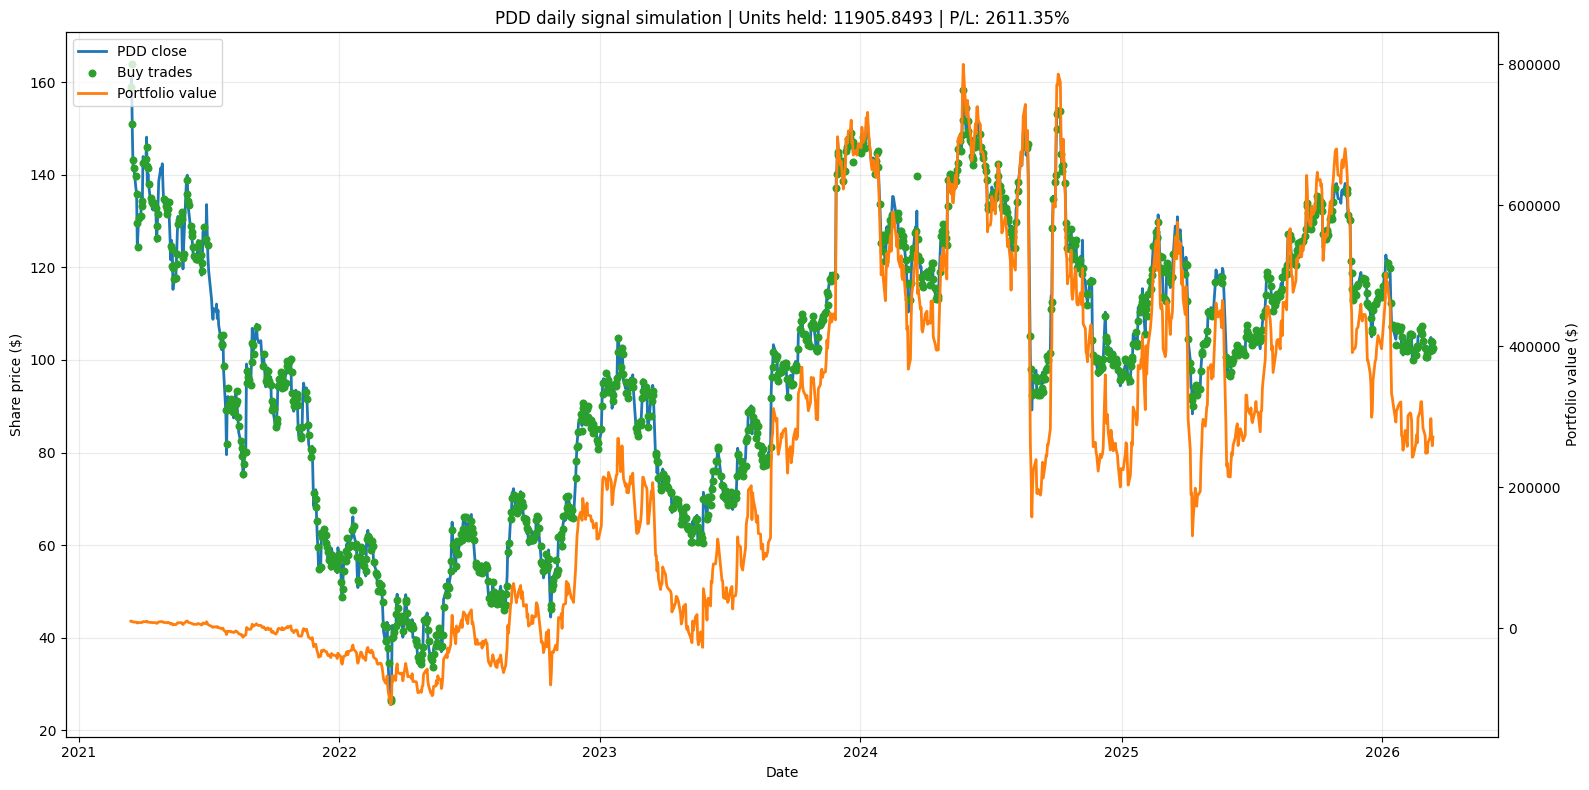

In [11]:
price_history = simulation_result["price_history"].copy()
daily_history = simulation_result["daily_history"].copy()
transactions = simulation_result["transactions"].copy()
simulation_summary = simulation_result["summary"].iloc[0]

buy_txns = transactions[transactions["action"] == "BUY"].copy()
sell_txns = transactions[transactions["action"] == "SELL"].copy()

fig, ax_price = plt.subplots(figsize=(16, 8))
ax_price.plot(
    price_history["Date"],
    price_history["Close"],
    color="#1f77b4",
    linewidth=2,
    label=f"{ticker} close",
)

if not buy_txns.empty:
    ax_price.scatter(
        buy_txns["Date"],
        buy_txns["trade_price"],
        color="#2ca02c",
        marker=".",
        s=90,
        label="Buy trades",
        zorder=5,
    )

if not sell_txns.empty:
    ax_price.scatter(
        sell_txns["Date"],
        sell_txns["trade_price"],
        color="#d62728",
        marker="v",
        s=90,
        label="Sell trades",
        zorder=5,
    )

ax_price.set_xlabel("Date")
ax_price.set_ylabel("Share price ($)")
ax_price.grid(alpha=0.25)

ax_portfolio = ax_price.twinx()
ax_portfolio.plot(
    daily_history["Date"],
    daily_history["portfolio_value"],
    color="#ff7f0e",
    linewidth=2,
    label="Portfolio value",
)
ax_portfolio.set_ylabel("Portfolio value ($)")

title = (
    f"{ticker} daily signal simulation | "
    f"Units held: {simulation_summary['units_held']:.4f} | "
    f"P/L: {simulation_summary['profit_loss_pct']:.2f}%"
)
ax_price.set_title(title)

handles_price, labels_price = ax_price.get_legend_handles_labels()
handles_portfolio, labels_portfolio = ax_portfolio.get_legend_handles_labels()
ax_price.legend(handles_price + handles_portfolio, labels_price + labels_portfolio, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Block 7: Daily Portfolio History


In [10]:
simulation_result["daily_history"][[
    "Date",
    "signal_text",
    "action",
    "trade_units",
    "trade_value",
    "cash_balance",
    "units_held",
    "holdings_value",
    "portfolio_value",
    "profit_loss_pct",
]].tail(60)


,Date,signal_text,action,trade_units,trade_value,cash_balance,units_held,holdings_value,portfolio_value,profit_loss_pct
1196,2025-12-16,WEAK BUY,BUY,4.582111,500.0,-913500.0,11550.197412,1.259202e+06,345702.483120,3357.024831
1197,2025-12-17,STRONG BUY,BUY,9.367681,1000.0,-914500.0,11559.565094,1.213754e+06,299254.334853,2892.543349
1198,2025-12-18,STRONG BUY,BUY,9.421962,1000.0,-915500.0,11568.987056,1.223883e+06,308383.151272,2983.831513
1199,2025-12-19,STRONG BUY,BUY,9.031384,1000.0,-916500.0,11578.018440,1.267909e+06,351408.824111,3414.088241
1200,2025-12-22,WEAK BUY,BUY,4.465282,500.0,-917000.0,11582.483722,1.296196e+06,379195.795797,3691.957958
1201,2025-12-23,WEAK BUY,BUY,4.463090,500.0,-917500.0,11586.946813,1.298433e+06,380933.231548,3709.332315
1202,2025-12-24,WEAK BUY,BUY,4.431053,500.0,-918000.0,11591.377866,1.314926e+06,396925.933369,3869.259334
1203,2025-12-26,WEAK BUY,BUY,4.362811,500.0,-918500.0,11595.740677,1.333626e+06,415126.160030,4051.261600
1204,2025-12-29,WEAK BUY,BUY,4.384426,500.0,-919000.0,11600.125103,1.324154e+06,405154.298260,3951.542983
1205,2025-12-30,WEAK BUY,BUY,4.382121,500.0,-919500.0,11604.507224,1.320941e+06,401441.078592,3914.410786
